In [53]:
from collections import defaultdict

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchlogix


In [28]:
def evaluate_model(model, loader, eval_functions, mode="eval"):
    """Evaluate model on a data loader with given evaluation functions.
    Assumes metrics can be computed in batches and averaged."""
    orig_mode = model.training
    model.train(mode == "train")

    metrics = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            preds = model(x)

            for name, fn in eval_functions.items():
                metrics[name].append(fn(preds, y).to(torch.float32).mean().item())

    model.train(orig_mode)

    return {name: np.mean(vals) for name, vals in metrics.items()}


def load_n(loader, n):
    i = 0
    while i < n:
        for x in loader:
            yield x
            i += 1
            if i == n:
                break

In [ ]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [ ]:
batch_size = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
binarization_layer = torchlogix.layers.FixedBinarization(thresholds=torch.tensor([[0.5000]]))
model = torch.nn.Sequential(
    binarization_layer,
    torch.nn.Flatten(),
    torchlogix.layers.LogicDense(in_dim=28*28, out_dim=1000), 
    torchlogix.layers.LogicDense(in_dim=1000, out_dim=1000), 
    torchlogix.layers.GroupSum(k=10, tau=1/0.3)
)

In [26]:
loss_fn = torch.nn.CrossEntropyLoss()
# Create evaluation functions
eval_functions = {
    "loss": loss_fn,
    "acc": lambda preds, y: (preds.argmax(-1) == y).to(torch.float32).mean(),
}
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [ ]:
num_iterations = 1000
eval_freq = 100
running_train_loss, n = 0.0, 0
metrics_dict = {"step": [], "test_acc_discrete": [], "test_loss_discrete": [], "test_acc_relaxed": [], "test_loss_relaxed": [], "train_loss": []}
for i, (x, y) in enumerate(load_n(train_loader, num_iterations)):
    model.train()
    x = model(x)
    loss = loss_fn(x, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    n += y.size(0)
    running_train_loss += loss
    # Evaluation
    if (eval_freq > 0 and ((i + 1) % eval_freq == 0)):
        # Evaluate on validation set
        discrete_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="eval"
        )
        relaxed_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="train"
        )

        metrics = \
            {f"test_{k}_discrete": v for k, v in discrete_metrics.items()} | \
            {f"test_{k}_relaxed": v for k, v in relaxed_metrics.items()} | \
            {"train_loss": running_train_loss.cpu().detach().item() / n * len(test_loader)}

        for k, v in metrics.items():
            metrics_dict[k].append(v)
        metrics_dict["step"].append(i + 1)

        print(f"Iteration {i + 1:6d} | " +
                " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()]))

        running_train_loss, n = 0.0, 0

Training:   0%|          | 0/1000 [00:00<?, ?it/s, loss=0.4842]

Training:  11%|█         | 111/1000 [00:04<00:38, 22.85it/s, loss=0.4477]

Iteration    100 | test_loss_discrete: 0.5258 | test_acc_discrete: 0.8451 | test_loss_relaxed: 0.4696 | test_acc_relaxed: 0.8761 | train_loss: 0.3029


Training:  18%|█▊        | 176/1000 [00:08<00:24, 34.32it/s, loss=0.5853]

Iteration    200 | test_loss_discrete: 0.5268 | test_acc_discrete: 0.8427 | test_loss_relaxed: 0.4682 | test_acc_relaxed: 0.8771 | train_loss: 0.3016


...

Iteration    800 | test_loss_discrete: 0.5254 | test_acc_discrete: 0.8427 | test_loss_relaxed: 0.4622 | test_acc_relaxed: 0.8784 | train_loss: 0.3003


Training:  91%|█████████ | 906/1000 [00:36<00:04, 21.01it/s, loss=0.4689]

Iteration    900 | test_loss_discrete: 0.5259 | test_acc_discrete: 0.8433 | test_loss_relaxed: 0.4611 | test_acc_relaxed: 0.8794 | train_loss: 0.3034


Training: 100%|██████████| 1000/1000 [00:41<00:00, 24.12it/s, loss=0.4267]

Iteration   1000 | test_loss_discrete: 0.5308 | test_acc_discrete: 0.8395 | test_loss_relaxed: 0.4604 | test_acc_relaxed: 0.8790 | train_loss: 0.2999


Text(0.5, 0.01, 'Training Step')

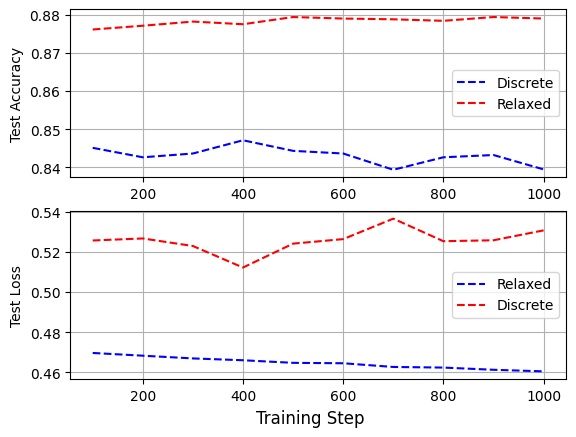

In [48]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1)
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_discrete"], "--", c="b", label="Discrete")
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_relaxed"], "--", c="r", label="Relaxed")
axs[0].set_ylabel("Test Accuracy")
axs[0].grid()
axs[0].legend()
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_relaxed"], "--", c="b", label="Relaxed")
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_discrete"], "--", c="r", label="Discrete")
axs[1].legend()
axs[1].set_ylabel("Test Loss")
axs[1].grid()
fig.supxlabel("Training Step")